# Outliers

1. Load the dataset

2. data test train split
   
3. Train Gradient Boosting model


4. Rolling-Origin Backtesting


5. Fine tuning the hyperparameters


6. Comparasion between different models


7. Conclusion




# 1. Load the dataset

In [224]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,FireplaceYN_missing,PoolPrivateYN_missing,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,1,0,6500.0,33.475311,-117.708995,1500.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
1,1,0,1800000.0,33.899427,-117.977995,3546.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
2,1,0,1200000.0,34.095980,-118.221993,1162.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
3,1,1,3200.0,33.773119,-116.343788,1873.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,0,0,0,False,False,False,False,False,False,True
4,1,0,1425000.0,33.884526,-117.778002,1672.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204344,1,0,865000.0,34.242304,-116.802871,2166.0,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
204345,1,1,4000.0,33.701018,-116.292460,2957.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
204346,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,1,0,1,False,False,False,True,False,False,False
204347,0,0,595000.0,37.824500,-122.281570,2502.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False


In [225]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204349 entries, 0 to 204348
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ViewYN                           204349 non-null  int64  
 1   PoolPrivateYN                    204349 non-null  int64  
 2   ClosePrice                       204349 non-null  float64
 3   Latitude                         204349 non-null  float64
 4   Longitude                        204349 non-null  float64
 5   LivingArea                       204349 non-null  float64
 6   MLSAreaMajor                     204349 non-null  object 
 7   CountyOrParish                   204349 non-null  object 
 8   ParkingTotal                     204349 non-null  float64
 9   PropertySubType                  204349 non-null  object 
 10  LotSizeAcres                     204349 non-null  float64
 11  YearBuilt                        204349 non-null  float64
 12  St

 feature engineering

In [226]:
data_clean_2=data_clean.copy()
data_clean_2["BedBathRatio"]= np.where(data_clean["BathroomsTotalInteger"] == 0,0, data_clean["BedroomsTotal"] / data_clean["BathroomsTotalInteger"])
data_clean_2["Years"]=2026-data_clean["YearBuilt"]

Adding more detailed geographic layer using school districts

In [227]:
import geopandas as gpd
districts=gpd.read_file('DistrictAreas2526_-284845464123469011.geojson')
districts_filter=districts[districts["DistrictType"]=="Unified"]
districts_filter

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,932,2025-26,0641580,5772694,57726940000000,Yolo,Washington Unified,Unified,PK,12,...,1,0.0,1242,15.1,3796,46.2,27.524200,13,"13 - City, Small","POLYGON ((-13538678.161 4660316.003, -13538674..."
927,933,2025-26,0642930,5772702,57727020000000,Yolo,Winters Joint Unified,Unified,PK,12,...,105,5.0,335,16.0,1185,56.7,126.903010,31,"31 - Town, Fringe","POLYGON ((-13578206.161 4668467.848, -13577796..."
928,934,2025-26,0643080,5772710,57727100000000,Yolo,Woodland Joint Unified,Unified,PK,12,...,296,3.2,1704,18.3,6827,73.4,309.459071,23,"23 - Suburban, Small","POLYGON ((-13580837.089 4696906.449, -13580814..."
930,936,2025-26,0624090,5872736,58727360000000,Yuba,Marysville Joint Unified,Unified,PK,12,...,47,0.4,1673,16.0,7648,73.2,462.497708,22,"22 - Suburban, Midsize","POLYGON ((-13540500.026 4756982.131, -13540491..."


In [228]:
#points from the data
points=gpd.GeoDataFrame(data_clean_2,geometry=gpd.points_from_xy(data_clean_2["Longitude"],data_clean_2["Latitude"]), crs="EPSG:4326")
districts_filter = districts_filter.to_crs("EPSG:4326")
points=gpd.sjoin(points,districts_filter,how="left",predicate="within")#Left Join
points.drop(columns=["index_right","OBJECTID","FedID"])#drop unrelated feature
points=points.dropna()

In [229]:
points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 76191 entries, 2 to 204348
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           76191 non-null  int64   
 1   PoolPrivateYN                    76191 non-null  int64   
 2   ClosePrice                       76191 non-null  float64 
 3   Latitude                         76191 non-null  float64 
 4   Longitude                        76191 non-null  float64 
 5   LivingArea                       76191 non-null  float64 
 6   MLSAreaMajor                     76191 non-null  object  
 7   CountyOrParish                   76191 non-null  object  
 8   ParkingTotal                     76191 non-null  float64 
 9   PropertySubType                  76191 non-null  object  
 10  LotSizeAcres                     76191 non-null  float64 
 11  YearBuilt                        76191 non-null  float64 
 12  

# 2. Test train valid split¶

In [230]:
X=12 # past month
months = sorted(points["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

date_ym
2025-07-01    5882
2026-04-01    5822
2026-05-01    5768
2025-08-01    5743
2025-10-01    5731
2026-03-01    5715
2025-09-01    5577
2025-12-01    5132
2025-11-01    4771
2026-02-01    4523
2026-01-01    4153
Name: count, dtype: int64
date_ym
2026-06-01    6044
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 58817 entries, 30699 to 187832
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           58817 non-null  int64   
 1   PoolPrivateYN                    58817 non-null  int64   
 2   ClosePrice                       58817 non-null  float64 
 3   Latitude                         58817 non-null  float64 
 4   Longitude                        58817 non-null  float64 
 5   LivingArea                       58817 non-null  float64 
 6   MLSAreaMajor                     58817 non-null  object  
 7   CountyOrParish 

In [231]:
lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

In [232]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# keep consistently
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [233]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

In [234]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58233 entries, 30699 to 187832
Columns: 160 entries, ViewYN to LocaleDesc_Other
dtypes: bool(101), float64(51), int64(8)
memory usage: 32.3 MB


# 3. Train  Gradient Boosting model (XGBoost and LightGBM)

In [235]:
results = []

## 3.1 XGBoost

In [236]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

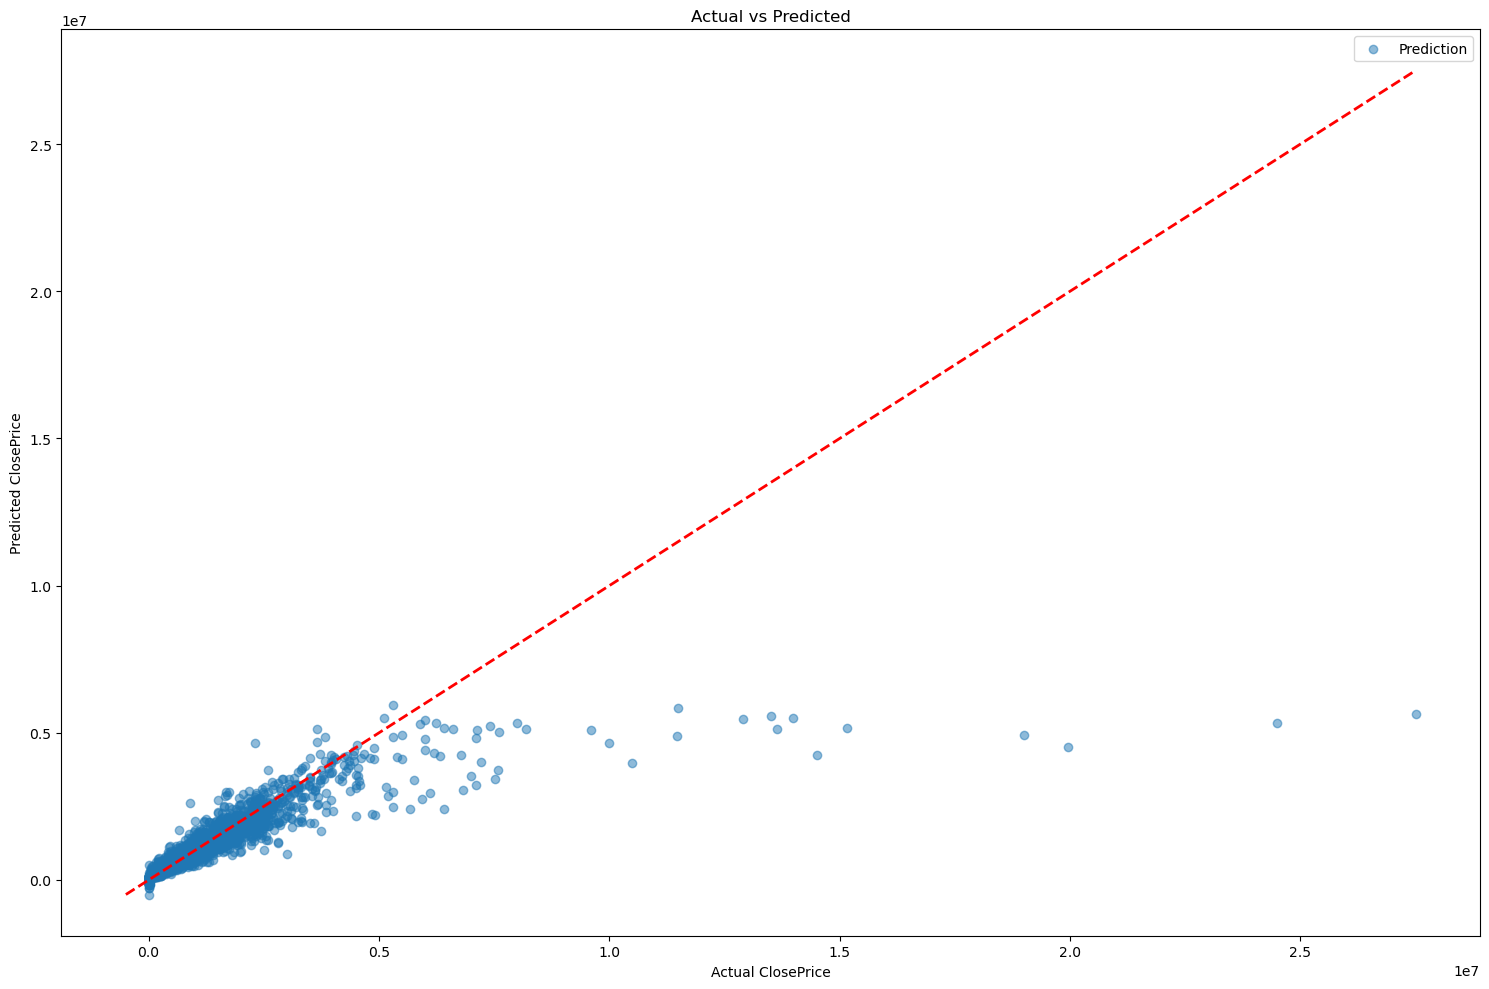

In [237]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [238]:
print(model.score(X_train, y_train))

0.9396060155485084


In [239]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"XGBoost",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 16.33%
MAPE : 1.8956
R²   : 0.6966
MAE  : 152279.3759
MSE  : 400351063187.6986
RMSE : 632733.0110


## 3.2 LightGBM

In [240]:
import re

X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_test.columns
]

In [241]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5080
[LightGBM] [Info] Number of data points in the train set: 58233, number of used features: 156
[LightGBM] [Info] Start training from score 716136.241938
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

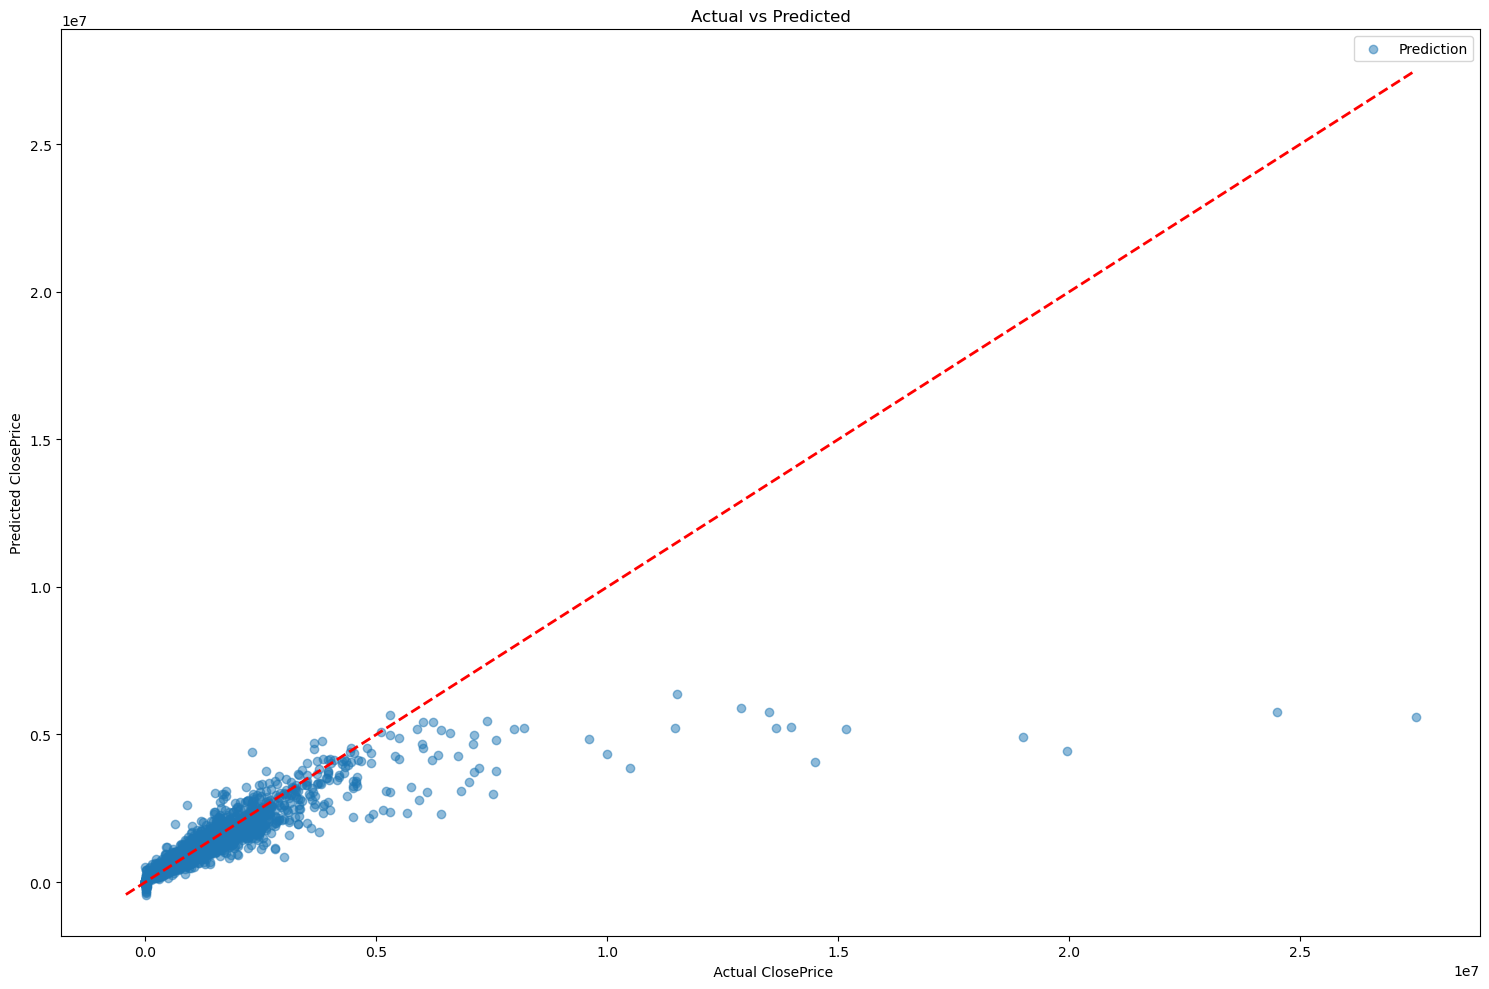

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.xlabel(" Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [243]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"LightGBM",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 16.88%
MAPE : 2.0862
R²   : 0.6964
MAE  : 155665.5819
MSE  : 400601394467.9570
RMSE : 632930.7975


In [244]:
print(model.score(X_train, y_train))

0.9292765674522696


# 4. Rolling-Origin Backtesting

In [245]:
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
result_roll_after=[]

for X in range(4,13):
    months = sorted(points["date_ym"].unique())
    data_train=points[points['date_ym'].isin(months[:X])]
    data_test=points[points['date_ym']==months[X]]
    # remove some outliers from train dataset
    lower=data_train["ClosePrice"].quantile(0.005)
    upper=data_train["ClosePrice"].quantile(0.995)
    data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

    cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
    for col in cols:
        top10 = data_train[col].value_counts().nlargest(10).index
        data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
        data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

    
    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"ElasticNet Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = DecisionTreeRegressor(max_depth=10,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------DecisionTree regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"Decision Tree Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Random Forest regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"Random Forest Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("-------------- XGBoost -------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"XGBoost",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })



    X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_train.columns]

    X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_test.columns ]
    model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("-------------- LightGBM -------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"LightGBM",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 34.30%
MAPE : 21.6751
R²   : 0.5187
MAE  : 296070.2163
MSE  : 445474009130.4698
RMSE : 667438.3935
--------------DecisionTree regression-------------
MdAPE: 14.78%
MAPE : 0.2356
R²   : 0.7307
MAE  : 171350.2802
MSE  : 249272046397.9752
RMSE : 499271.5157
--------------Random Forest regression-------------
MdAPE: 9.72%
MAPE : 0.2275
R²   : 0.7680
MAE  : 127022.6368
MSE  : 214788755837.3330
RMSE : 463453.0784
-------------- XGBoost -------------
MdAPE: 16.28%
MAPE : 1.8963
R²   : 0.7769
MAE  : 133885.7145
MSE  : 206494639562.5009
RMSE : 454416.8126
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005046 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4790
[LightGBM] [Info] Number of data points in the train set: 22732, number of used features: 152
[LightGBM] [Info] Start training from score 706792.736055
[LightGBM] [Warning] No further splits with

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 31.46%
MAPE : 62.0702
R²   : 0.5046
MAE  : 302899.8601
MSE  : 528441026681.5571
RMSE : 726939.4931
--------------DecisionTree regression-------------
MdAPE: 15.14%
MAPE : 0.9015
R²   : 0.6690
MAE  : 177678.3164
MSE  : 353118313871.2554
RMSE : 594237.5904
--------------Random Forest regression-------------
MdAPE: 9.61%
MAPE : 1.4943
R²   : 0.7237
MAE  : 132175.9382
MSE  : 294791376418.5231
RMSE : 542946.9370
-------------- XGBoost -------------
MdAPE: 15.90%
MAPE : 5.0606
R²   : 0.7436
MAE  : 142791.1472
MSE  : 273494948651.0133
RMSE : 522967.4451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4835
[LightGBM] [Info] Number of data points in the train set: 28252, number of used features: 152
[LightGBM] [Info] Start training from score 705583.625690
[LightGBM] [Warning] No further splits with

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

...

--------------ElasticNet regression-------------
MdAPE: 33.03%
MAPE : 21.5096
R²   : 0.5140
MAE  : 312487.0940
MSE  : 515989036968.4305
RMSE : 718323.7689
--------------DecisionTree regression-------------
MdAPE: 15.78%
MAPE : 0.2463
R²   : 0.7400
MAE  : 184065.1511
MSE  : 276046425785.2626
RMSE : 525401.2046
--------------Random Forest regression-------------
MdAPE: 9.13%
MAPE : 0.1936
R²   : 0.7888
MAE  : 129813.5726
MSE  : 224206659399.5999
RMSE : 473504.6562
-------------- XGBoost -------------
MdAPE: 16.44%
MAPE : 1.8332
R²   : 0.7918
MAE  : 144746.6578
MSE  : 221010669545.8840
RMSE : 470117.7188
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010996 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5115
[LightGBM] [Info] Number of data points in the train set: 52313, number of used features: 156
[LightGBM] [Info] Start training from score 709426.112493
[LightGBM] [Warning] No further splits with

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 32.36%
MAPE : 24.0792
R²   : 0.4807
MAE  : 314597.5057
MSE  : 575949223784.3834
RMSE : 758913.1859
--------------DecisionTree regression-------------
MdAPE: 15.26%
MAPE : 0.2512
R²   : 0.6807
MAE  : 179703.8654
MSE  : 354075983409.1968
RMSE : 595042.8417
--------------Random Forest regression-------------
MdAPE: 9.08%
MAPE : 0.1755
R²   : 0.7249
MAE  : 128045.5840
MSE  : 305086548578.1340
RMSE : 552346.4027
-------------- XGBoost -------------
MdAPE: 16.74%
MAPE : 1.8321
R²   : 0.7346
MAE  : 142999.4258
MSE  : 294316689285.9715
RMSE : 542509.6214
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012911 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5135
[LightGBM] [Info] Number of data points in the train set: 57974, number of used features: 156
[LightGBM] [Info] Start training from score 711782.671522
[LightGBM] [Warning] No further splits with

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 32.72%
MAPE : 24.3414
R²   : 0.5374
MAE  : 315263.0493
MSE  : 469255003671.9225
RMSE : 685021.9001
--------------DecisionTree regression-------------
MdAPE: 14.69%
MAPE : 0.2630
R²   : 0.7203
MAE  : 176430.1073
MSE  : 283679555957.8654
RMSE : 532615.7677
--------------Random Forest regression-------------
MdAPE: 8.83%
MAPE : 0.1964
R²   : 0.7765
MAE  : 125832.8986
MSE  : 226700141376.0627
RMSE : 476130.3827
-------------- XGBoost -------------
MdAPE: 16.27%
MAPE : 1.8278
R²   : 0.7816
MAE  : 140943.4592
MSE  : 221509119102.1880
RMSE : 470647.5530
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5157
[LightGBM] [Info] Number of data points in the train set: 63735, number of used features: 156
[LightGBM] [Info] Start training from score 713548.742098
[LightGBM] [Warning] No further splits with

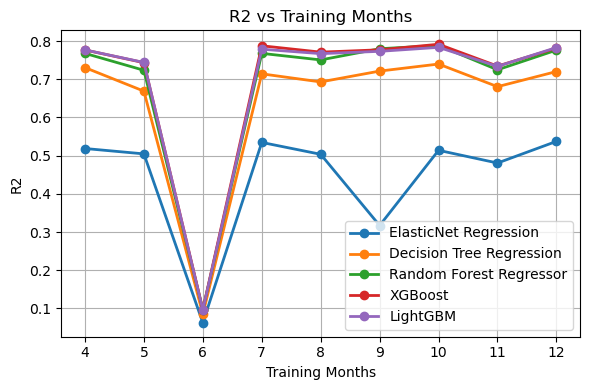

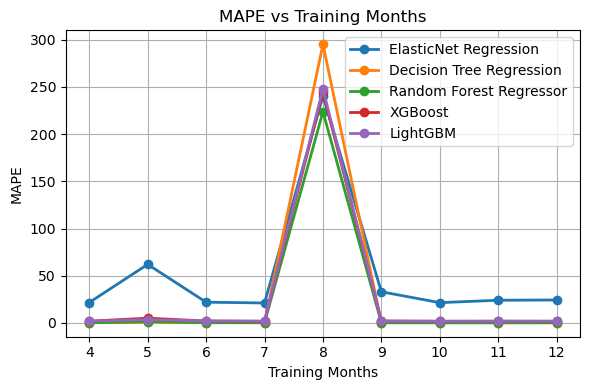

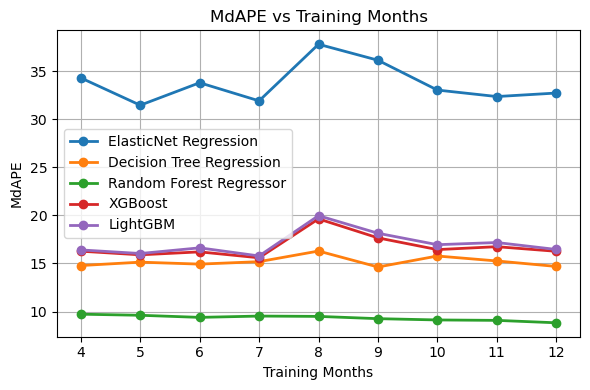

In [246]:
#plot
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(result_roll_after)
models = df["model"].unique()

metrics = ["R2", "MAPE", "MdAPE"]

for metric in metrics:
    plt.figure(figsize=(6,4))

    for model in models:
        temp = df[df["model"] == model].sort_values("train-test-X")
        plt.plot(
            temp["train-test-X"],
            temp[metric],
            marker="o",
            linewidth=2,
            label=model
        )

    plt.xlabel("Training Months")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Training Months")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [247]:
# record the result

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
pd.DataFrame(result_roll_after).to_csv("model_result_roll_7.csv",index=True)    

# 5. Fine tuning the hyperparameters

# 5.1 LightGBM

In [248]:
X=12 # past month
months = sorted(points["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]


X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_test.columns
]

date_ym
2025-07-01    5882
2026-04-01    5822
2026-05-01    5768
2025-08-01    5743
2025-10-01    5731
2026-03-01    5715
2025-09-01    5577
2025-12-01    5132
2025-11-01    4771
2026-02-01    4523
2026-01-01    4153
Name: count, dtype: int64
date_ym
2026-06-01    6044
Name: count, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 58817 entries, 30699 to 187832
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           58817 non-null  int64   
 1   PoolPrivateYN                    58817 non-null  int64   
 2   ClosePrice                       58817 non-null  float64 
 3   Latitude                         58817 non-null  float64 
 4   Longitude                        58817 non-null  float64 
 5   LivingArea                       58817 non-null  float64 
 6   MLSAreaMajor                     58817 non-null  object  
 7   CountyOrParish 

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [249]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58233 entries, 30699 to 187832
Columns: 160 entries, ViewYN to LocaleDesc_Other
dtypes: bool(101), float64(51), int64(8)
memory usage: 32.3 MB


In [250]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

def mdape(y_true, y_pred):
    ape = np.abs((y_true - y_pred) / y_true)
    return np.median(ape) * 100

mdape_scorer = make_scorer(
    mdape,
    greater_is_better=False 
)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "random_state": 42,
    }

    model = LGBMRegressor(**params)
    #score = cross_val_score(model, X_train, y_train,cv=5,scoring="r2").mean()
    score = cross_val_score(model, X_train, y_train,cv=5,scoring=mdape_scorer).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print(study.best_params)

[I 2026-08-06 01:32:14,908] A new study created in memory with name: no-name-2e6237be-105a-4af9-a344-4e228cc34f1b


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4982
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [Info] Start training from score 719070.925670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 156
[LightGBM] [Info] Start training from score 716912.437080
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5009
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [In

[I 2026-08-06 01:32:21,335] Trial 0 finished with value: -14.396287730965605 and parameters: {'n_estimators': 580, 'max_depth': 15, 'learning_rate': 0.10634581911992862}. Best is trial 0 with value: -14.396287730965605.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010340 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4982
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [Info] Start training from score 719070.925670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 156
[LightGBM] [Info] Start training from score 716912.437080
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5009
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [In

[I 2026-08-06 01:32:25,906] Trial 1 finished with value: -17.53836768770157 and parameters: {'n_estimators': 272, 'max_depth': 18, 'learning_rate': 0.021237089659778007}. Best is trial 0 with value: -14.396287730965605.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4982
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [Info] Start training from score 719070.925670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011607 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 156
[LightGBM] [Info] Start training from score 716912.437080
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5009
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [In

[I 2026-08-06 01:36:01,321] Trial 38 finished with value: -15.251588442380093 and parameters: {'n_estimators': 342, 'max_depth': 13, 'learning_rate': 0.07247878285889778}. Best is trial 24 with value: -14.243196599740596.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4982
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [Info] Start training from score 719070.925670
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009479 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5033
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 156
[LightGBM] [Info] Start training from score 716912.437080
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009862 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5009
[LightGBM] [Info] Number of data points in the train set: 46586, number of used features: 155
[LightGBM] [In

[I 2026-08-06 01:36:04,294] Trial 39 finished with value: -15.382660324299176 and parameters: {'n_estimators': 232, 'max_depth': 15, 'learning_rate': 0.10596439613456363}. Best is trial 24 with value: -14.243196599740596.


{'n_estimators': 634, 'max_depth': 16, 'learning_rate': 0.14077544525284386}


In [251]:
# Test： using best parameters
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=634,
    learning_rate=0.14077544525284386,
    max_depth=16,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5080
[LightGBM] [Info] Number of data points in the train set: 58233, number of used features: 156
[LightGBM] [Info] Start training from score 716136.241938


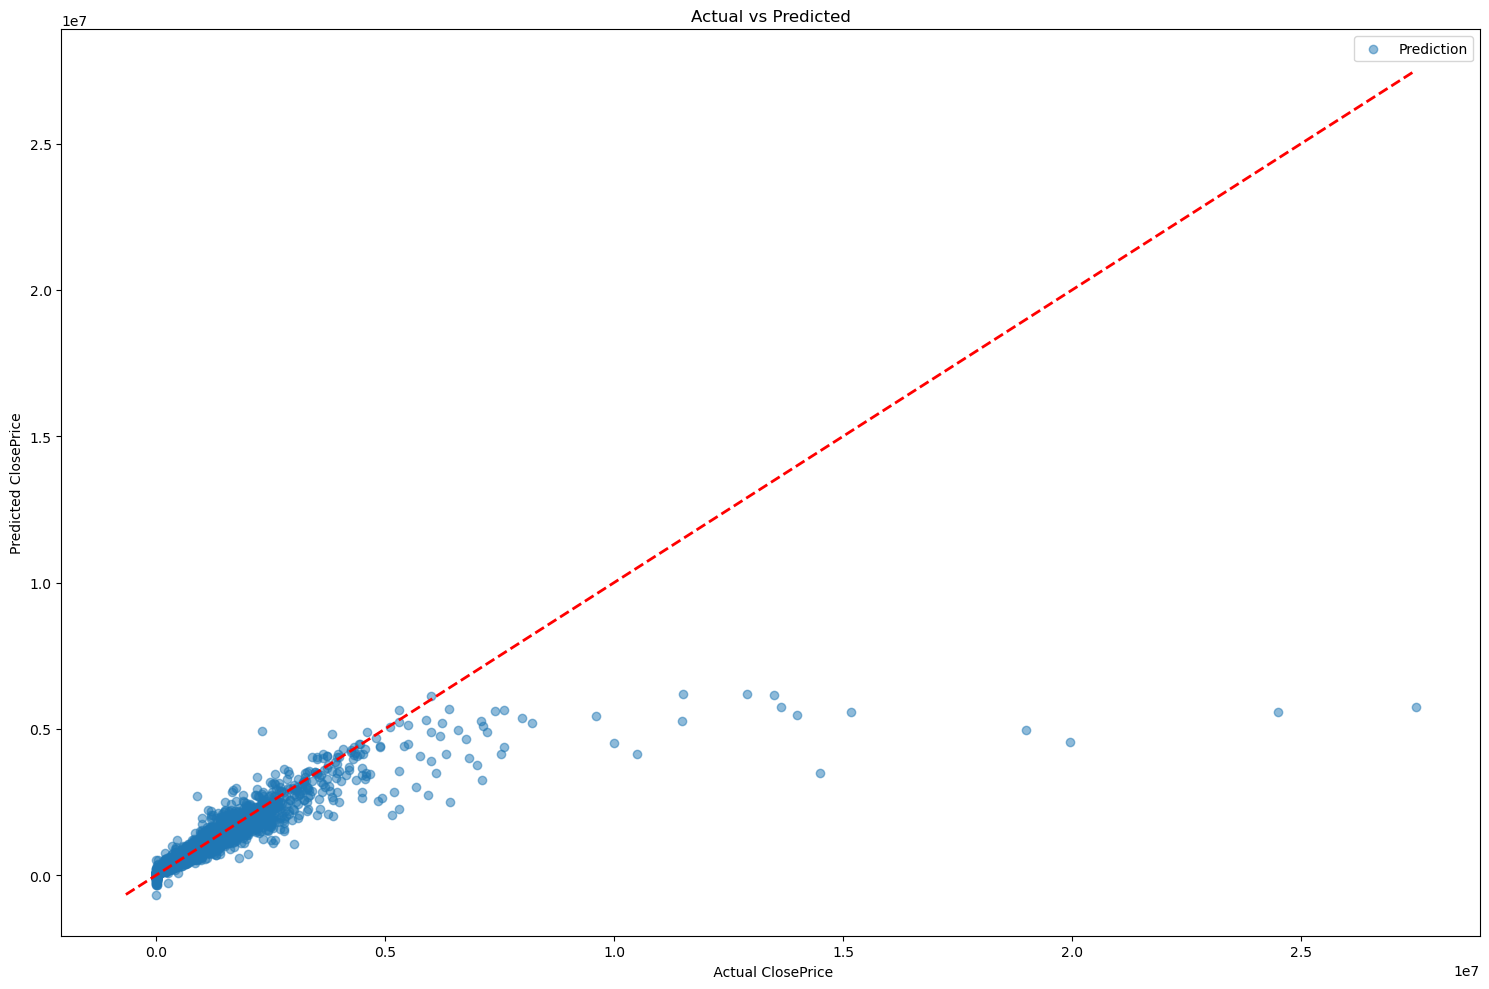

In [252]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

#  y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel(" Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [253]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MdAPE: 14.44%
MAPE : 1.7920
R²   : 0.7122
MAE  : 140642.2193
MSE  : 379804873463.8627
RMSE : 616283.1115


feature importance

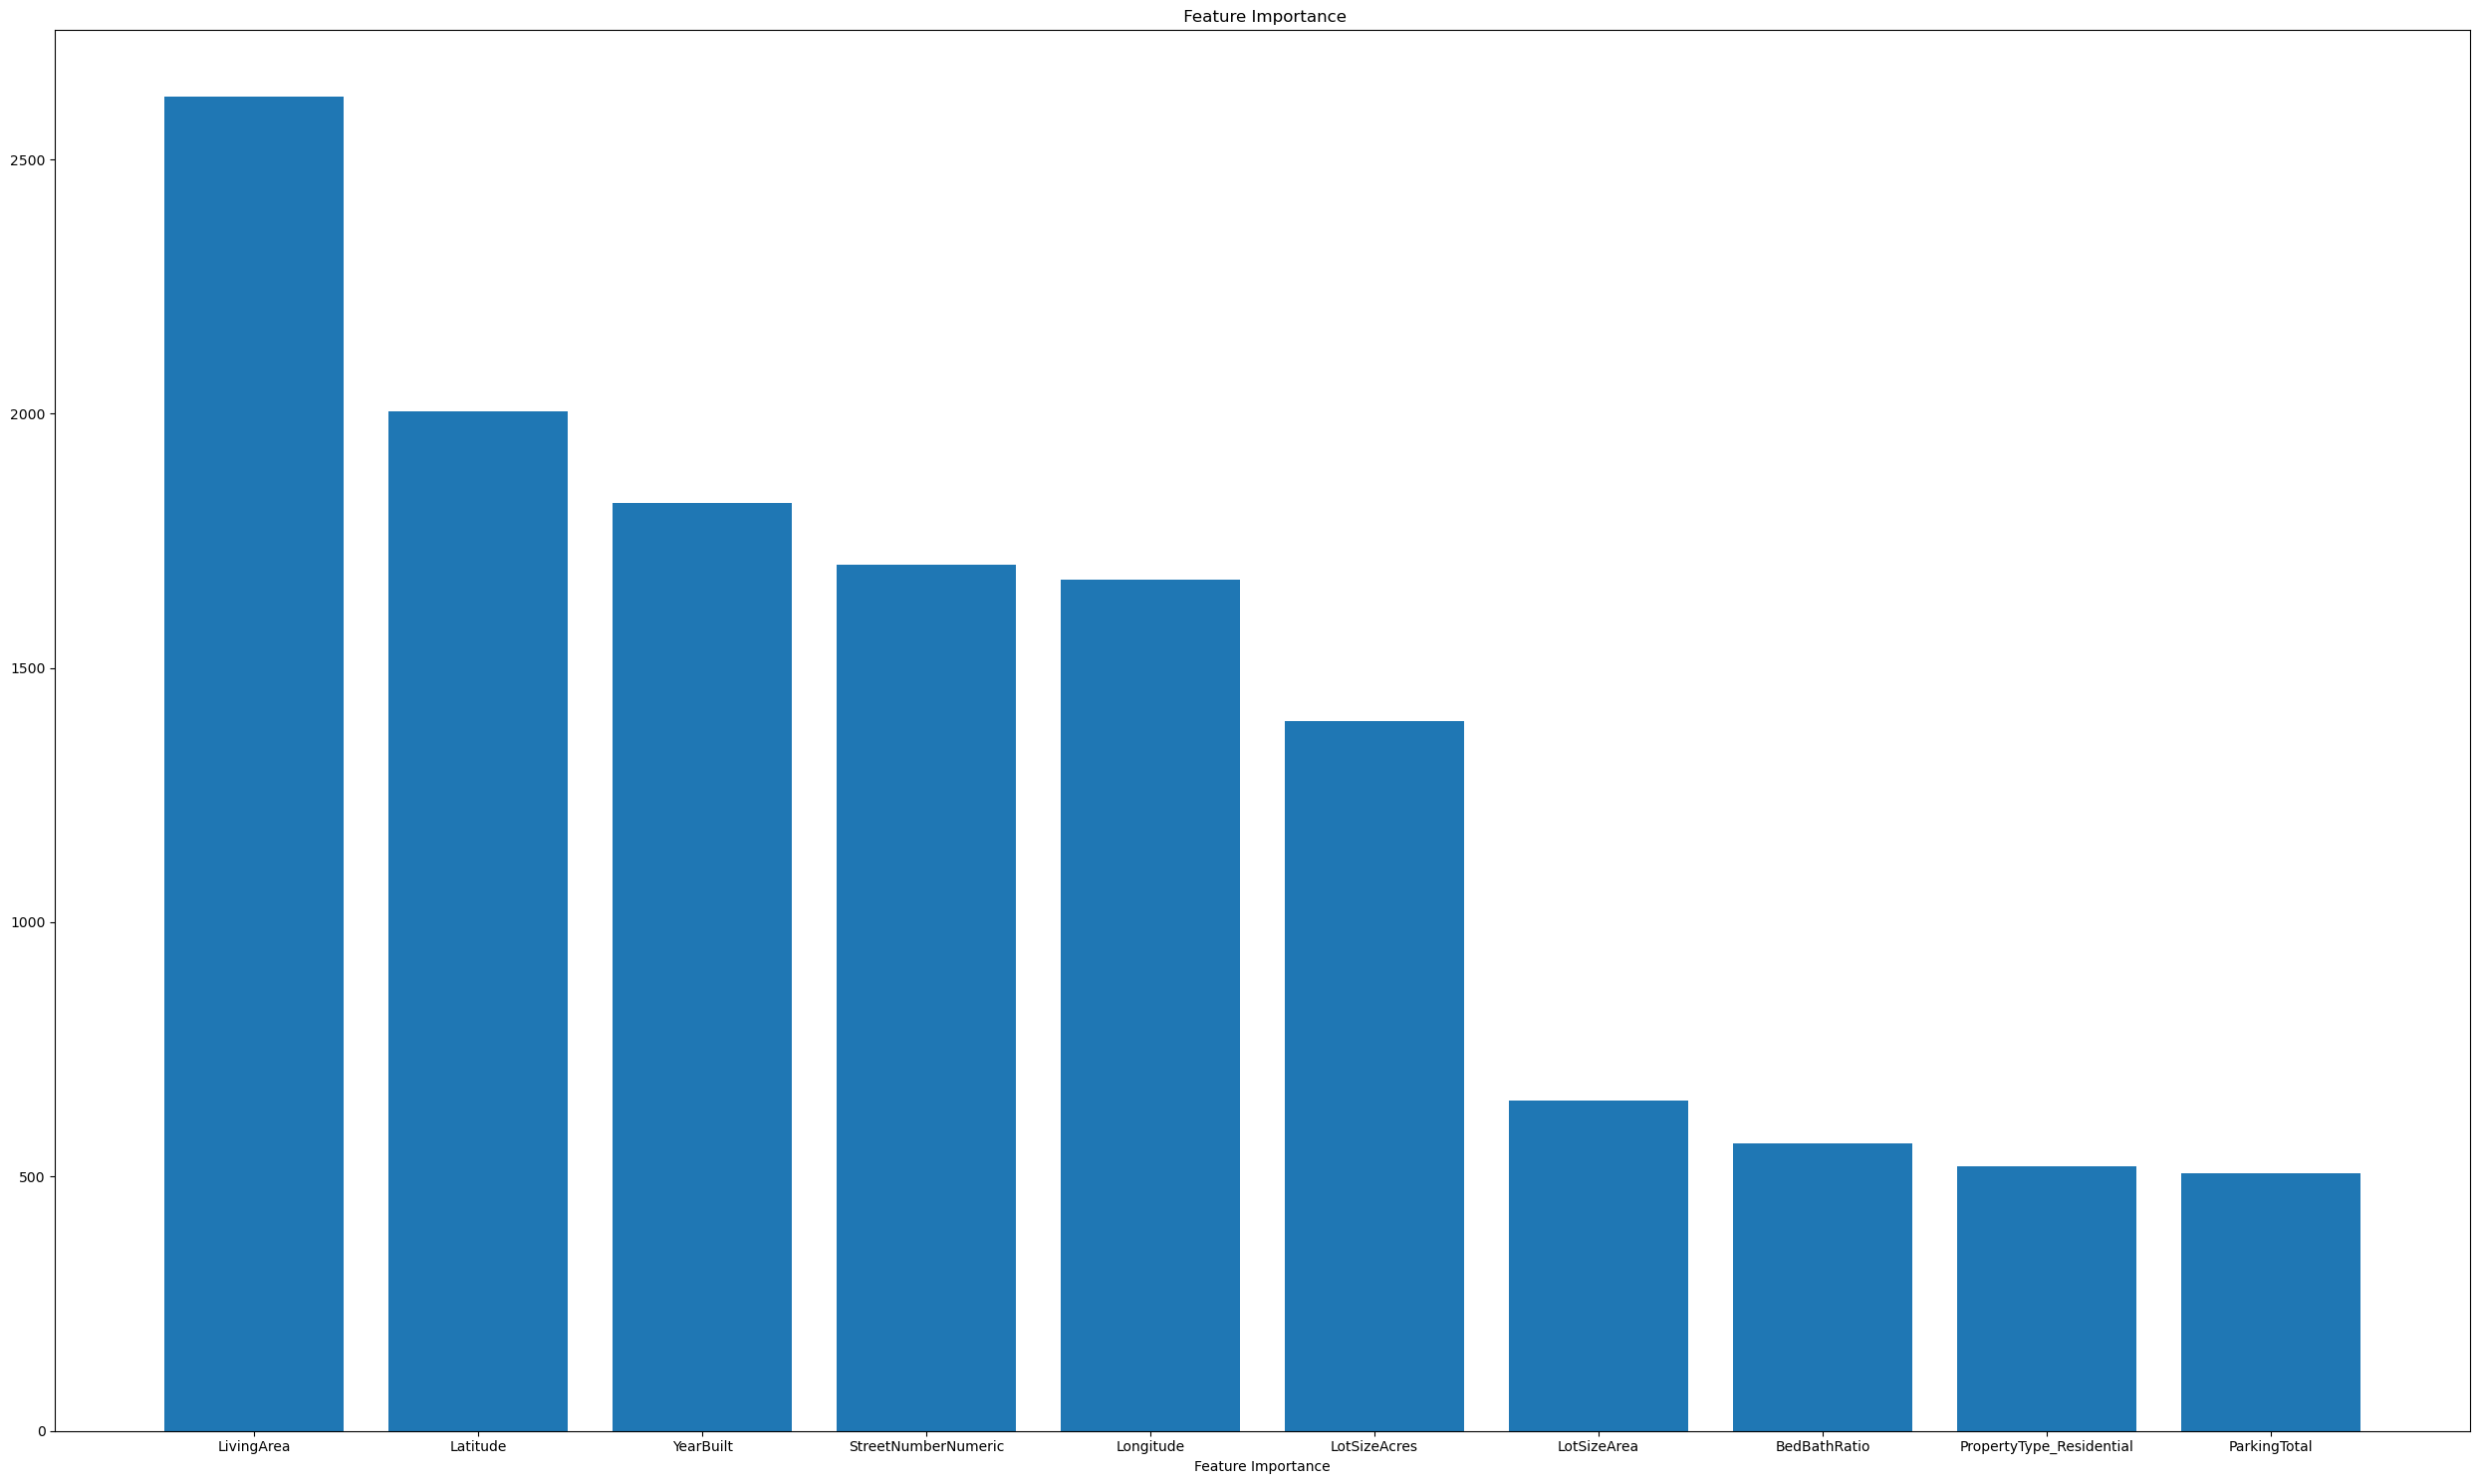

In [254]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title(" Feature Importance")
plt.tight_layout()
plt.show()

## 5.2 XGBoost

In [255]:
import optuna
from sklearn.model_selection import cross_val_score
def mdape(y_true, y_pred):
    ape = np.abs((y_true - y_pred) / y_true)
    return np.median(ape) * 100

mdape_scorer = make_scorer(
    mdape,
    greater_is_better=False  # 越小越好
)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "random_state": 42,
        "subsample":0.8,
        "colsample_bytree":0.8,
        "random_state":42
    }

    model = XGBRegressor(**params)
    #score = cross_val_score(model, X_train, y_train,cv=5,scoring="r2").mean()
    score = cross_val_score(model, X_train, y_train,cv=5,scoring=mdape_scorer).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print(study.best_params)

[I 2026-08-06 01:37:29,855] A new study created in memory with name: no-name-d5e8e56c-79ca-469a-b5be-3e0aa4f8a36b
[I 2026-08-06 01:37:49,802] Trial 0 finished with value: -13.416375594651843 and parameters: {'n_estimators': 672, 'max_depth': 9, 'learning_rate': 0.028551121117274158}. Best is trial 0 with value: -13.416375594651843.
[I 2026-08-06 01:38:57,878] Trial 1 finished with value: -13.608830215840362 and parameters: {'n_estimators': 183, 'max_depth': 17, 'learning_rate': 0.20842186701827928}. Best is trial 0 with value: -13.416375594651843.
[I 2026-08-06 01:40:29,858] Trial 2 finished with value: -13.794783782298861 and parameters: {'n_estimators': 532, 'max_depth': 13, 'learning_rate': 0.15155968078991552}. Best is trial 0 with value: -13.416375594651843.
[I 2026-08-06 01:40:50,877] Trial 3 finished with value: -16.711159713054514 and parameters: {'n_estimators': 173, 'max_depth': 13, 'learning_rate': 0.012814819968123062}. Best is trial 0 with value: -13.416375594651843.
[I 20

{'n_estimators': 243, 'max_depth': 18, 'learning_rate': 0.03574013578339181}


In [256]:
# Test： using best parameters
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=243,
    learning_rate=0.03574013578339181,
    max_depth=18,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

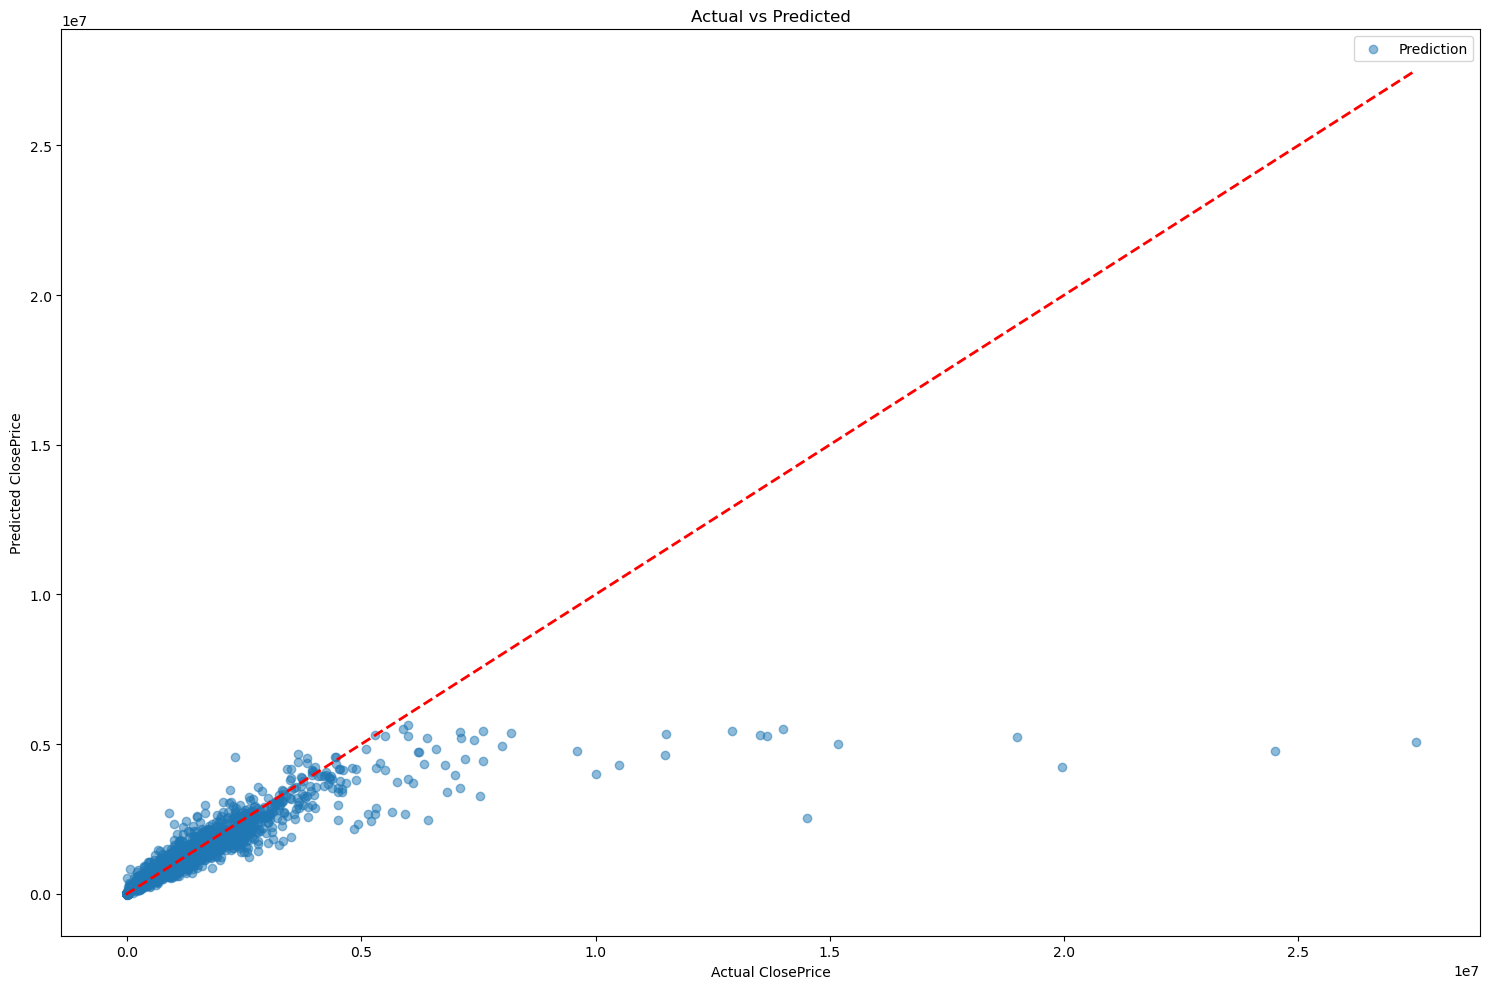

In [257]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

feature importance

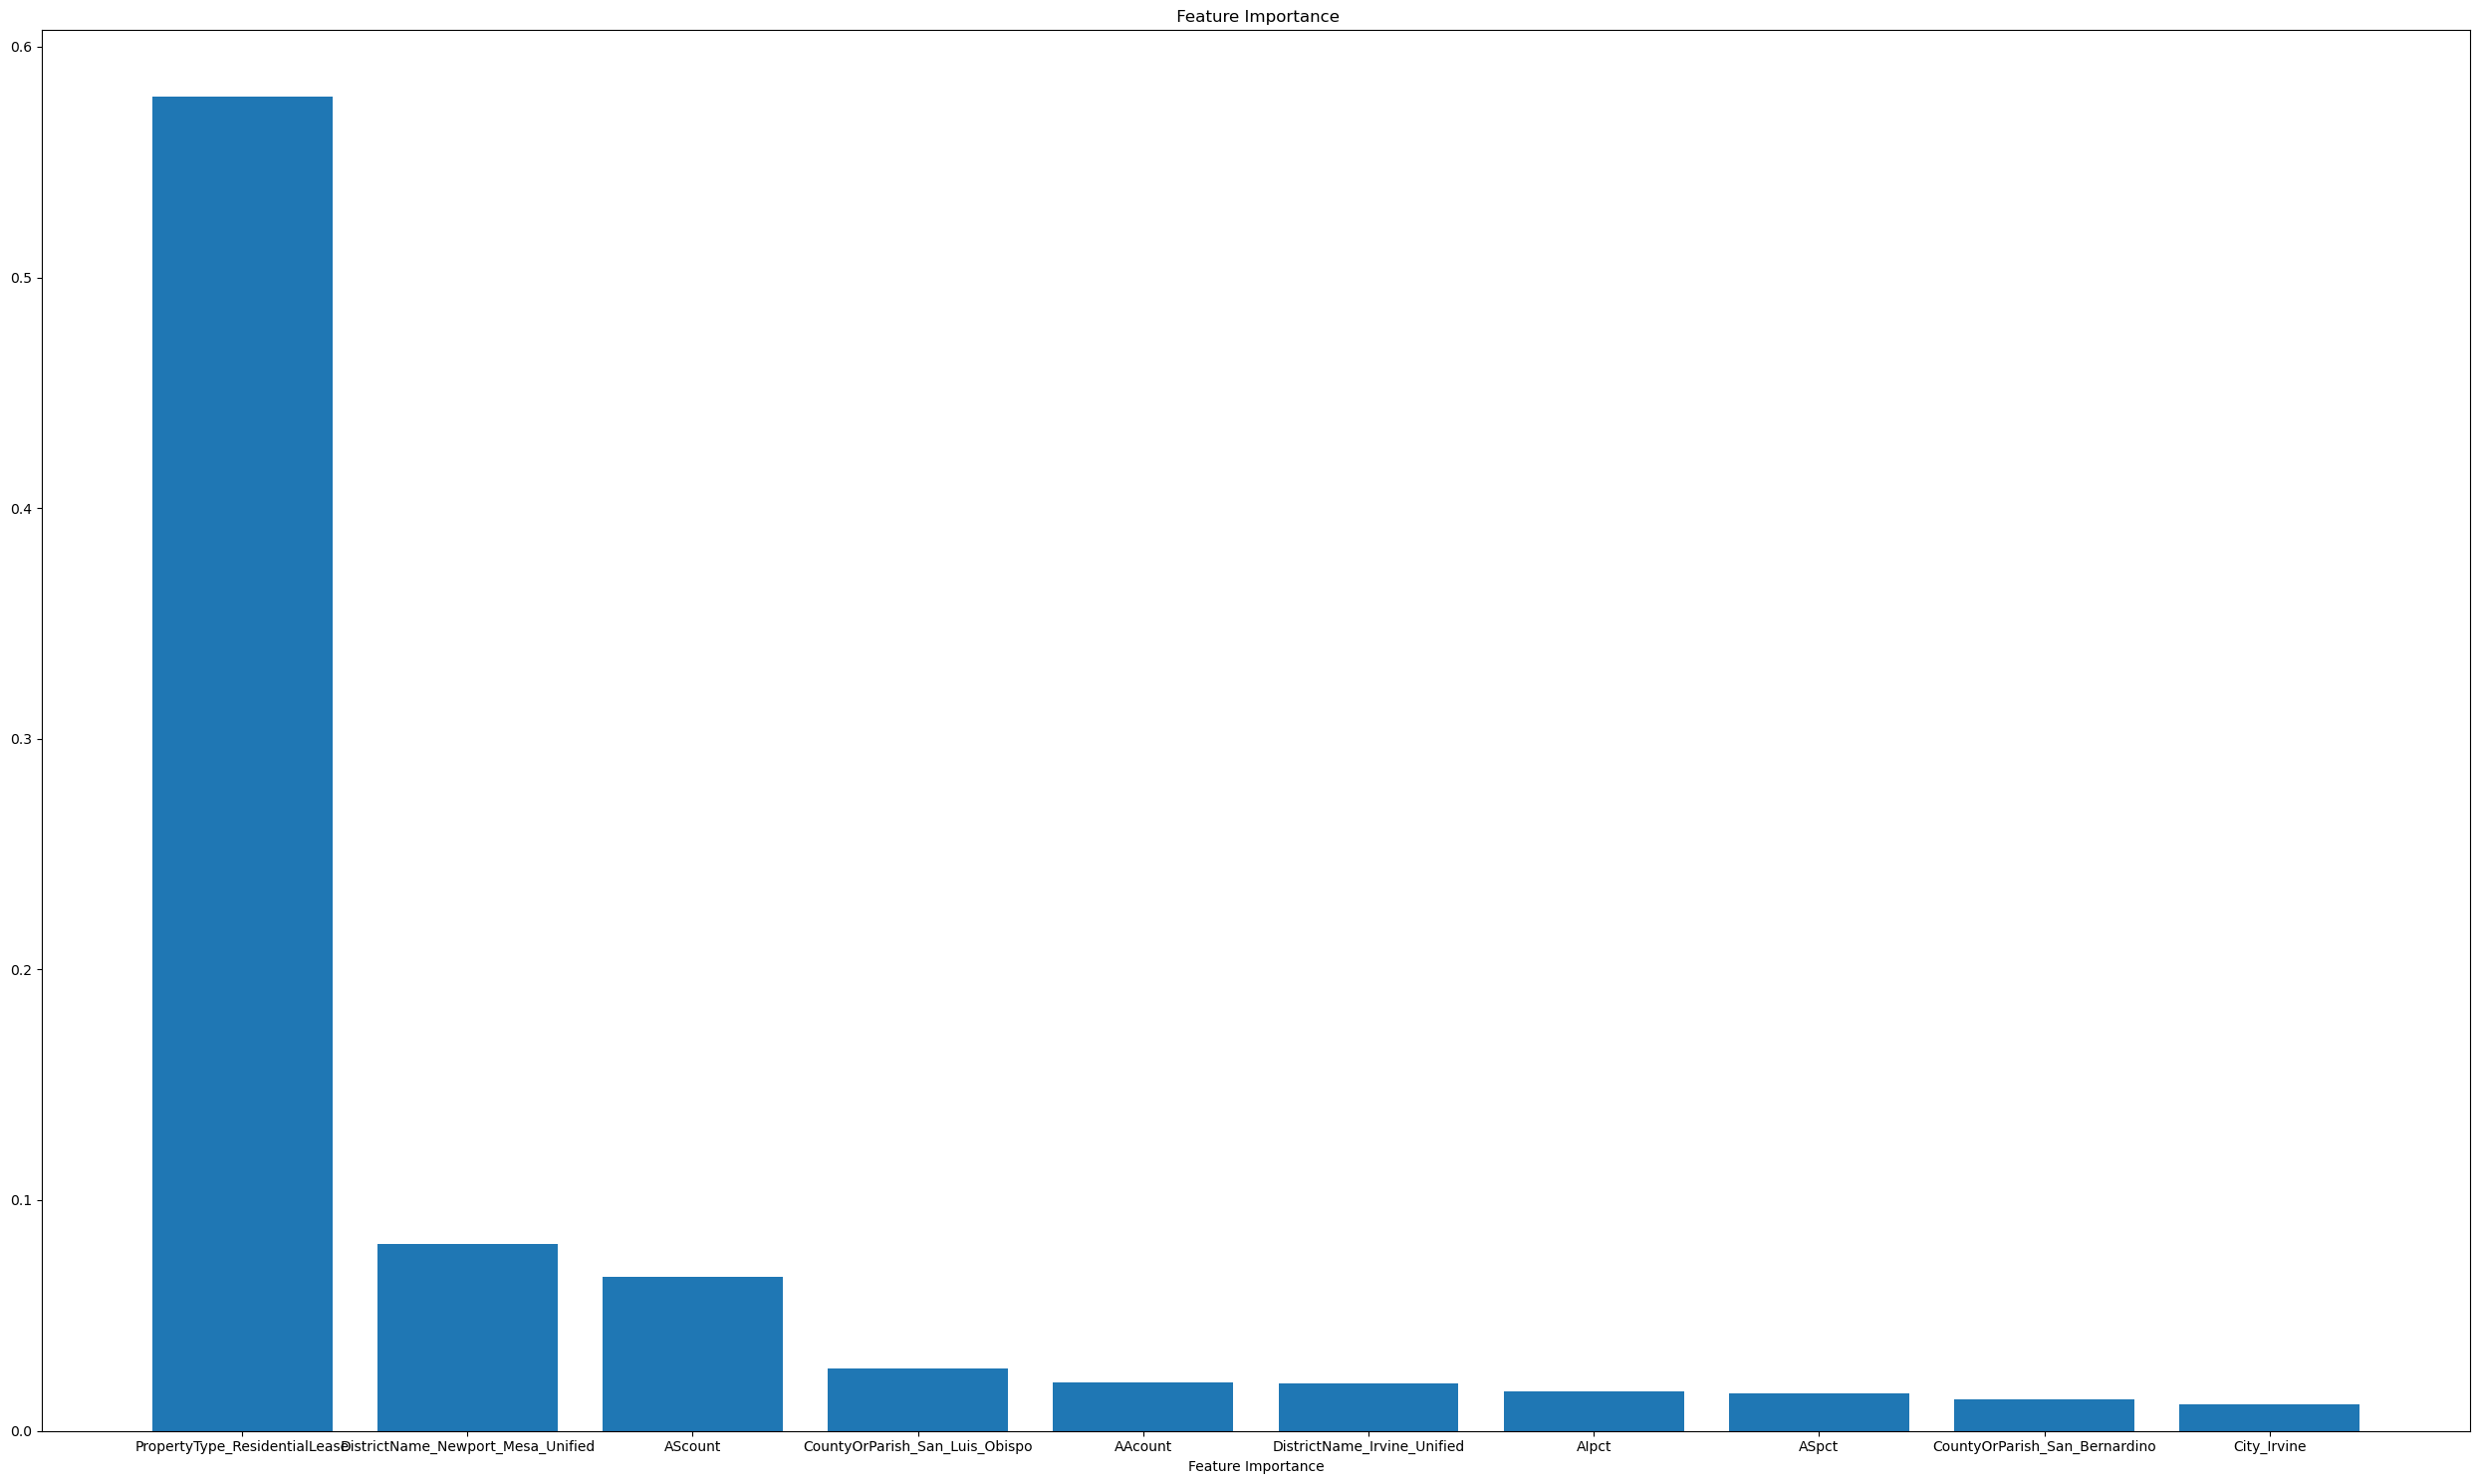

In [258]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title(" Feature Importance")
plt.tight_layout()
plt.show()

In [259]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MdAPE: 11.86%
MAPE : 0.4357
R²   : 0.6918
MAE  : 134340.3082
MSE  : 406641692511.4814
RMSE : 637684.6341


# 6. Comparsion between different models

In [260]:
X=12
months = sorted(points["date_ym"].unique())
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
# remove some outliers from train dataset
lower=data_train["ClosePrice"].quantile(0.005)
upper=data_train["ClosePrice"].quantile(0.995)
data_train = data_train[(data_train["ClosePrice"] >= lower) & (data_train["ClosePrice"] <= upper)]

cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# keep the cols consistently
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [261]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58233 entries, 30699 to 187832
Columns: 160 entries, ViewYN to LocaleDesc_Other
dtypes: bool(101), float64(51), int64(8)
memory usage: 32.3 MB


## 6.1 ElasticNet --- baseline

In [262]:
model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) 
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
print("--------------ElasticNet regression-------------")
print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

--------------ElasticNet regression-------------
MdAPE: 32.93%
MAPE : 21.7937
R²   : -0.5648
MAE  : 347199.8244
MSE  : 2064798236125.2278
RMSE : 1436940.5820


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.953e+15, tolerance: 3.470e+12
  model = cd_fast.enet_coordinate_descent(


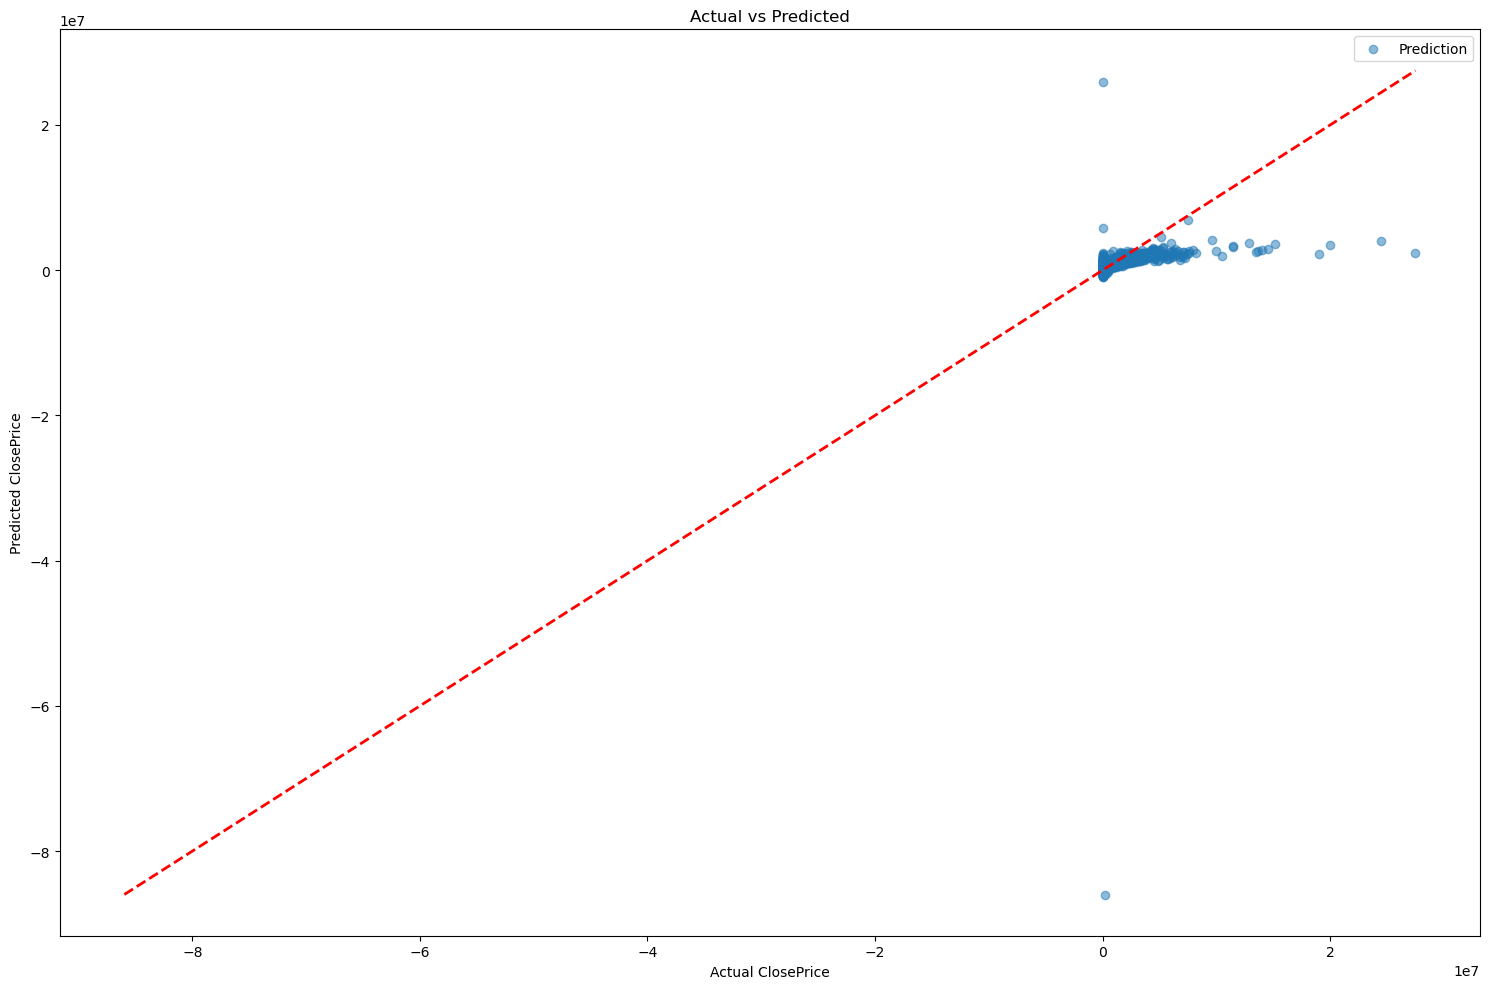

In [263]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 6.2 Decesion tree

In [264]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

MdAPE: 14.66%
MAPE : 0.4398
R²   : 0.6446
MAE  : 194431.0412
MSE  : 468984833016.9718
RMSE : 684824.6732


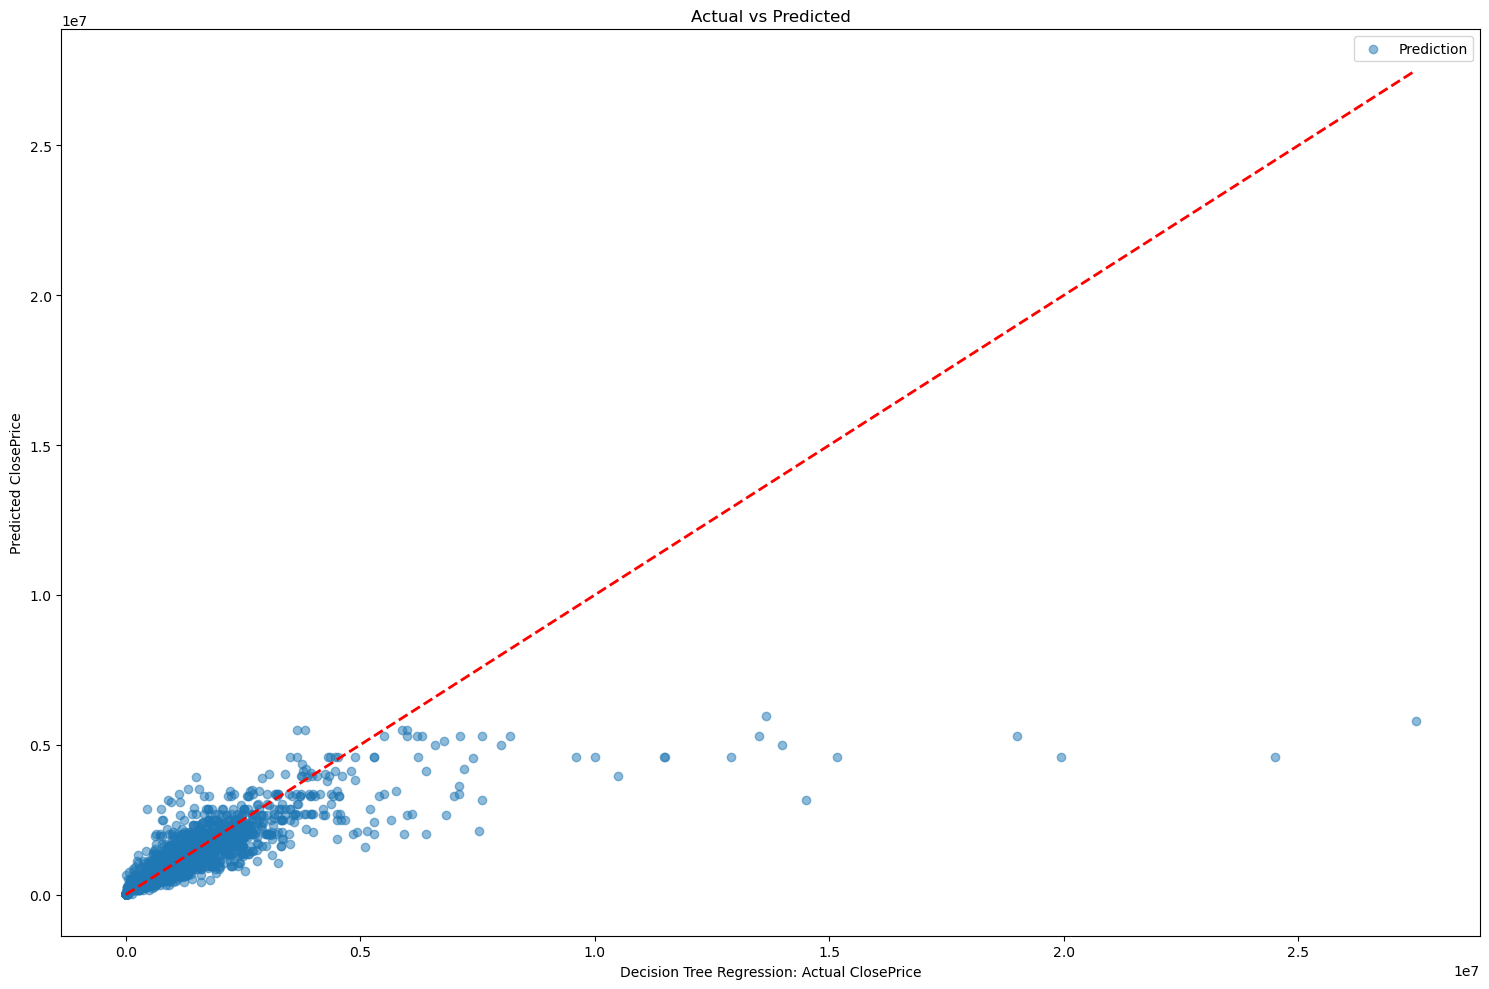

In [265]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Decision Tree Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 6.3 Random forest

In [266]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


MdAPE: 9.13%
MAPE : 0.3477
R²   : 0.6889
MAE  : 138977.8248
MSE  : 410503540580.8824
RMSE : 640705.5022


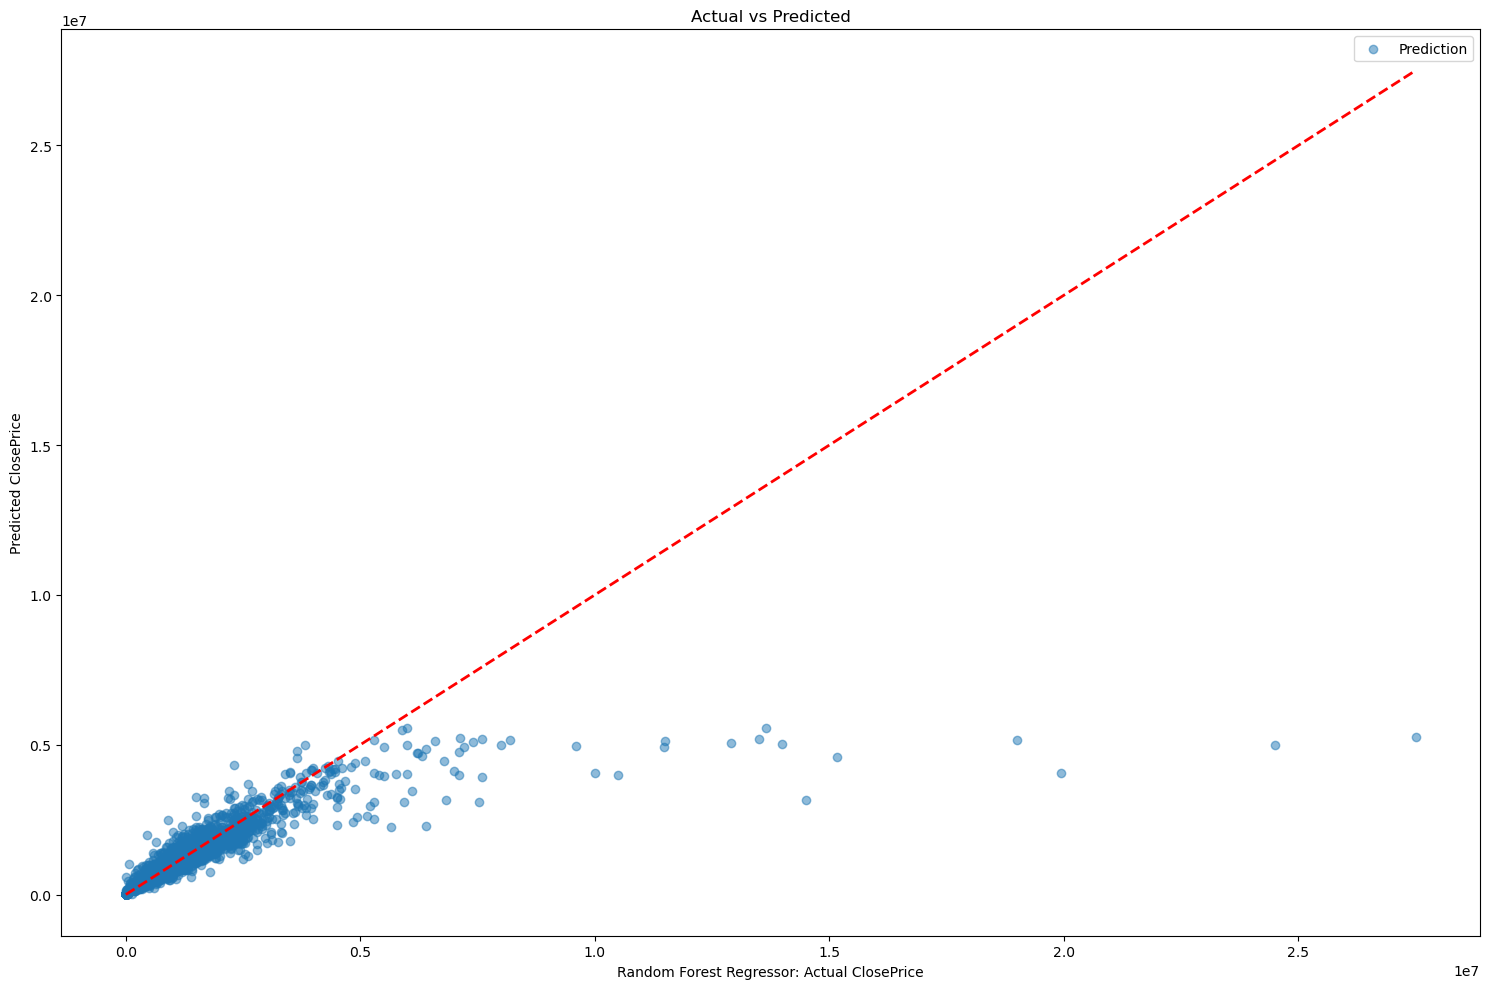

In [267]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 6.4 XGBoost

In [269]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=243,
    learning_rate=0.03574013578339181,
    max_depth=18,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


MdAPE: 11.86%
MAPE : 0.4357
R²   : 0.6918
MAE  : 134340.3082
MSE  : 406641692511.4814
RMSE : 637684.6341


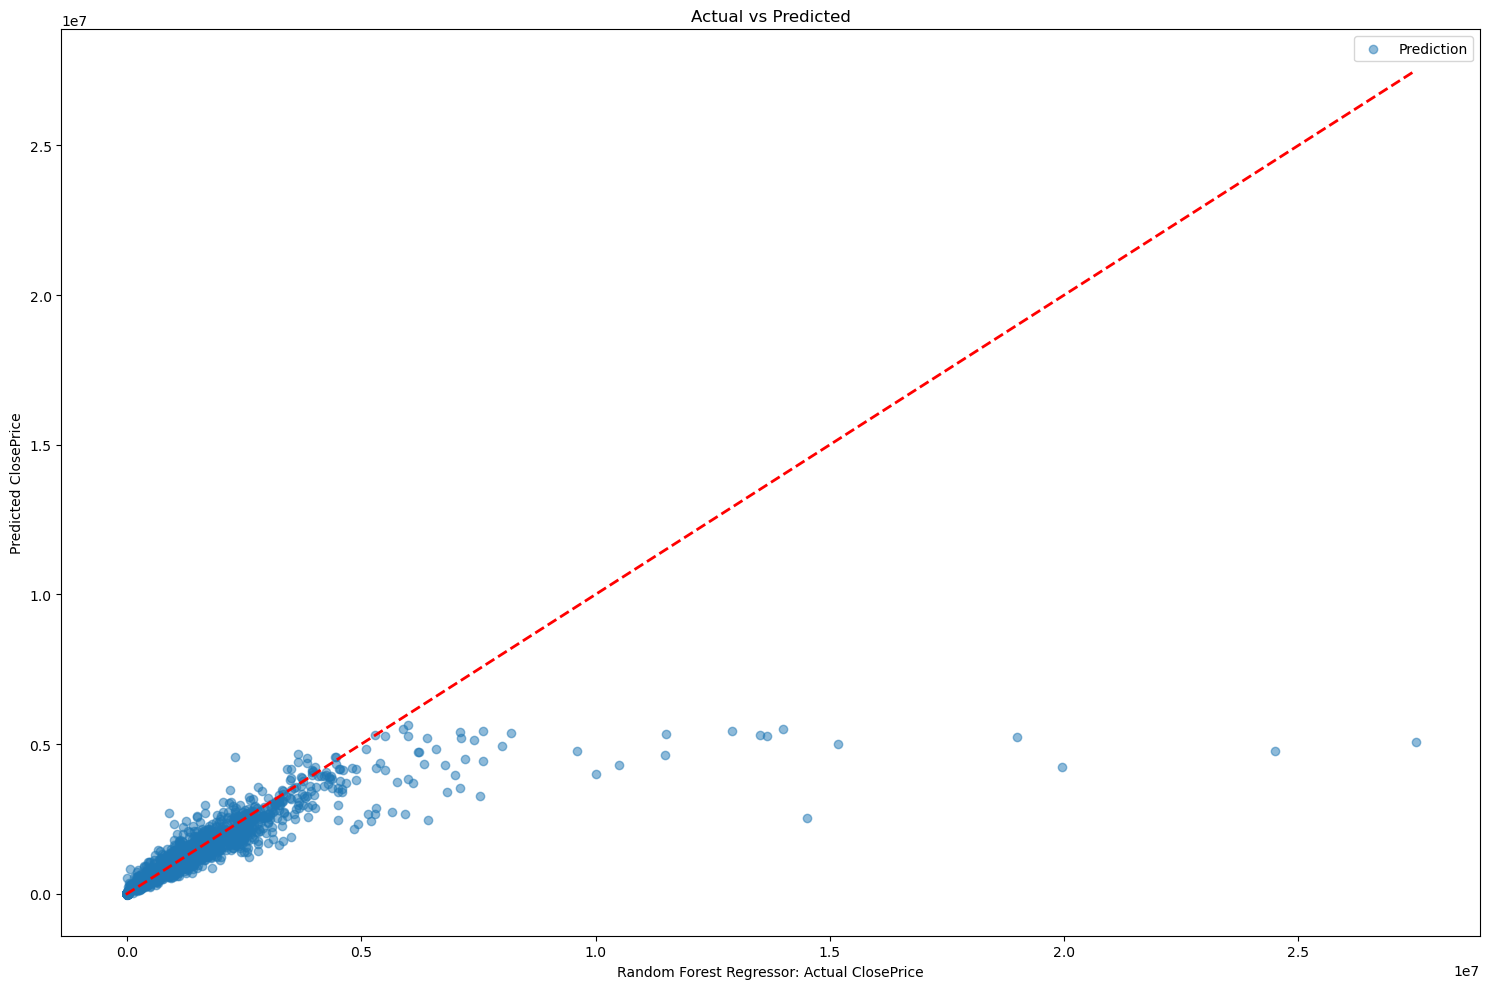

In [270]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

## 6.5 LightGBM

In [271]:
X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', c)
    for c in X_test.columns
]

In [272]:
model = LGBMRegressor(
    n_estimators=634,
    learning_rate=0.14077544525284386,
    max_depth=16,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5080
[LightGBM] [Info] Number of data points in the train set: 58233, number of used features: 156
[LightGBM] [Info] Start training from score 716136.241938
MdAPE: 14.44%
MAPE : 1.7920
R²   : 0.7122
MAE  : 140642.2193
MSE  : 379804873463.8627
RMSE : 616283.1115


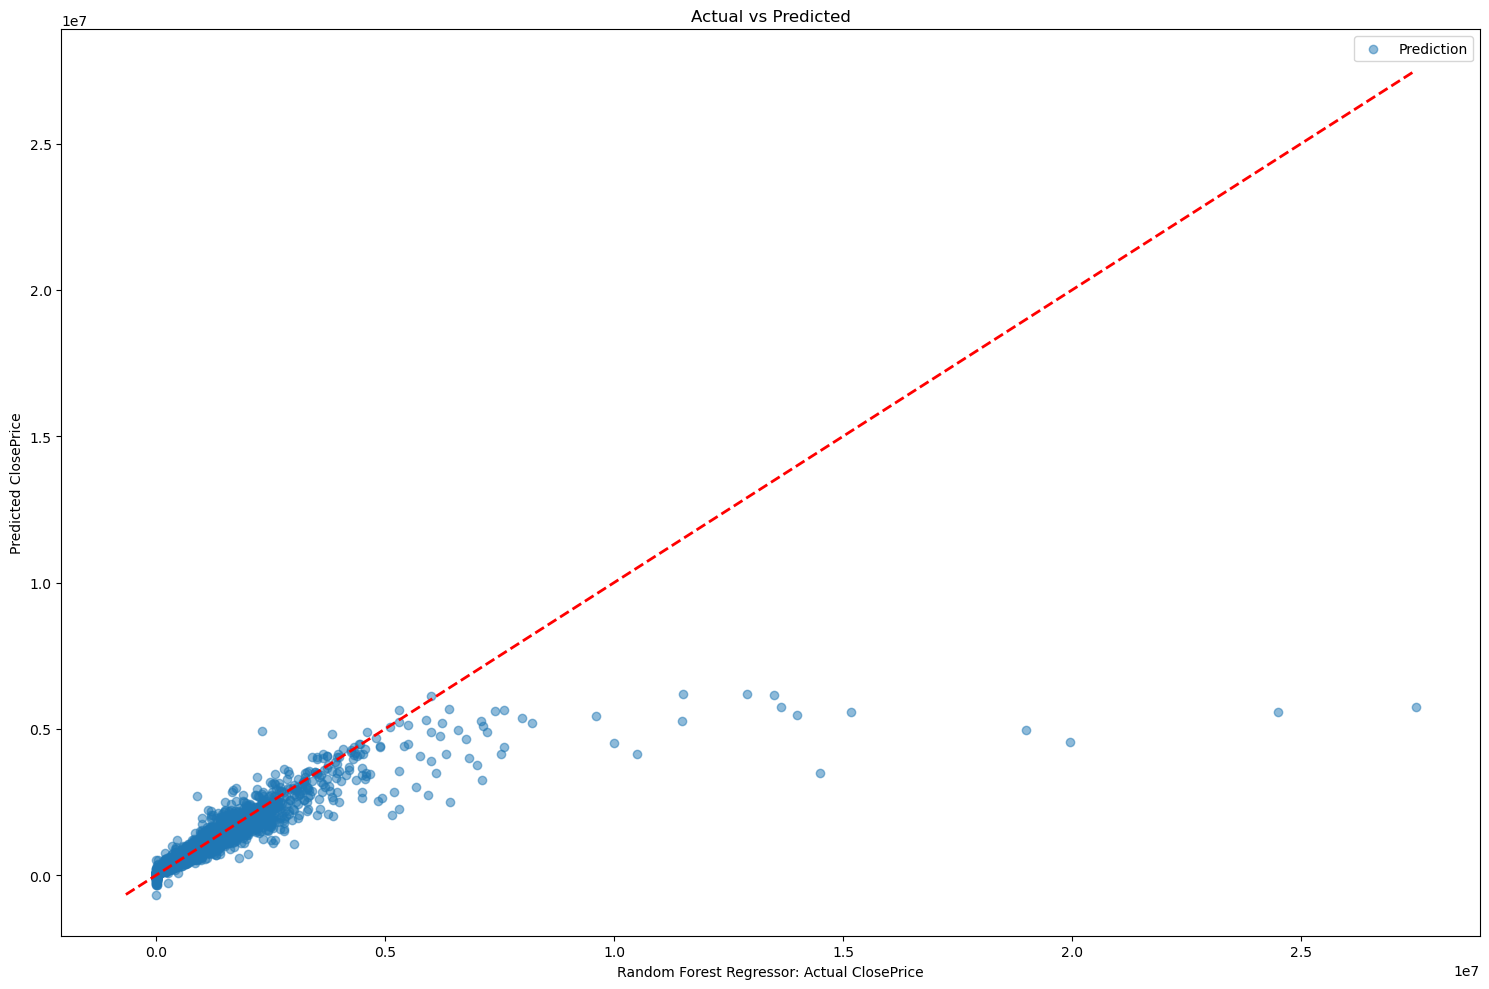

In [273]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

# 7. Conclusion

## Model Comparison

Five regression models were evaluated using **MdAPE**, **MAPE**, and **R²**.

| Model | MdAPE (%) ↓ | MAPE ↓ | R² ↑ |
|:----------------|-----------:|---------:|------:|
| ElasticNet | 32.93 | 21.7937 | -0.5648 |
| Decision Tree | 14.66 | 0.4398 | 0.6446 |
| Random Forest | **9.13** | **0.3477** | 0.6889 |
| XGBoost | 11.86 | 0.4357 | 0.6918 |
| LightGBM | 14.44 | 1.7920 | **0.7122** |

### Discussion

- **ElasticNet** produced the weakest performance, with a **negative R² (-0.5648)** and the highest **MdAPE (32.93%)**, indicating that a linear model is insufficient for capturing the nonlinear relationships in the housing dataset. The negative R² suggests that the model performed even worse than simply predicting the mean house price.

- **Decision Tree** significantly improved the results, increasing **R²** to **0.6446** while reducing **MdAPE** to **14.66%**. This demonstrates that introducing nonlinear decision boundaries enables the model to capture much more of the variance in house prices than the linear baseline.

- **Random Forest** achieved the **lowest MdAPE (9.13%)** and **lowest MAPE (0.3477)**, indicating the smallest prediction errors while maintaining a relatively high **R² (0.6889)**. Although its R² is slightly lower than those of XGBoost and LightGBM, the substantially lower MdAPE indicates that Random Forest provides more accurate predictions for individual house prices.

- **XGBoost** obtained a slightly higher **R² (0.6918)** than Random Forest but had higher **MdAPE (11.86%)** and **MAPE (0.4357)**, suggesting a slightly better overall fit but less accurate predictions in terms of relative error.

- **LightGBM** achieved the highest **R² (0.7122)**, indicating the best overall fit among all evaluated models. However, its **MdAPE (14.44%)** and **MAPE (1.7920)** were considerably higher than those of Random Forest, implying larger prediction errors despite explaining more variance in the data.

### Conclusion

Although **LightGBM** achieved the highest **R²**, indicating the strongest overall fitting ability, **Random Forest** obtained the lowest **MdAPE** and **MAPE**, providing the most accurate predictions with the smallest relative errors. Since the improvement in **R²** from Random Forest to LightGBM is relatively small, while the increase in **MdAPE** is much larger, **Random Forest** provides a better balance between model fit and prediction accuracy. Therefore, **Random Forest** is selected as the final model for this project.